# QFM (Quantum Flow Matching) — 项目跑通指南 + 数学原理

本 notebook 帮助你**从零跑通**整个 QFM 项目（预处理 → 训练 → 推理），并把每一步背后的**数学原理**讲清楚。

## 一、项目是做什么的？

QFM 是一个 **极简版的文生图（Text-to-Image）模型**，相当于一个迷你版 Flux/Stable Diffusion。整体架构：

```
Prompt ──┬─► CLIP-L      ─► clip_vec    (1, 768)        ┐
         └─► Qwen2.5-1.5B ─► qwen_context(1, 128, 1536)  │ (作为条件 c)
                                                          ▼
Image ──► SDXL-VAE-Encoder ─► latent (4, H/8, W/8) ──► [DiT + MoE 主干]
                                                          │
                                  Flow-Matching 训练 (预测速度场 v)
                                                          ▼
                          Euler ODE 采样 ──► VAE-Decoder ──► 生成图像
```

### 关键技术点
| 模块 | 一句话原理 |
|---|---|
| **Flow Matching (Rectified Flow)** | 在噪声 $x_0$ 与真实 latent $x_1$ 之间画一条直线，让网络学**速度场** $v=x_1-x_0$ |
| **DiT (Diffusion Transformer)** | 用 Transformer 替代 U-Net，通过 **AdaLN-Zero** 注入时间 / 文本条件 |
| **Sparse MoE (Top-2)** | 每个 token 仅激活 8 个专家中得分最高的 2 个，并加 load-balance 辅助 loss |
| **多分辨率分桶** | 7 种宽高比，位置编码 bicubic 插值适配任意分辨率 |
| **EMA + bf16-mixed** | 影子权重平滑 + 混合精度提速省显存 |

### 数学符号约定（贯穿全篇）
| 符号 | 含义 |
|---|---|
| $x_0 \sim \mathcal{N}(0, I)$ | 纯高斯噪声（4×H×W latent） |
| $x_1 \sim p_{\text{data}}$ | 真实图像经 VAE 编码后的 latent |
| $t \in [0, 1]$ | 流时间，$t=0$ 是噪声、$t=1$ 是数据 |
| $x_t$ | $x_0$ 与 $x_1$ 之间的插值点 |
| $v_\theta(x_t, t, c)$ | 网络预测的**速度场**（条件为文本 $c$） |
| $c = (\text{clip\_vec}, \text{qwen\_ctx})$ | 文本条件（pooled 768 维 + 序列 128×1536 维） |

## 二、环境准备

切到项目根目录，并把 `src/` 加入 `sys.path`，确保后续 cell 能 `import qfm`。

In [3]:
import os
import pathlib
import sys

# 当前 notebook 在 docs/ 下，项目根是上一级
PROJECT_ROOT = pathlib.Path.cwd()
if PROJECT_ROOT.name == "docs":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("Project root:", PROJECT_ROOT)
print("Files       :", sorted(p.name for p in PROJECT_ROOT.iterdir()))

Project root: /home/yao/projects/QFM
Files       : ['.claude', '.git', '.gitignore', '.idea', '.pre-commit-config.yaml', '.ruff_cache', 'checkpoints', 'data', 'docs', 'main.py', 'pyproject.toml', 'readme.md', 'src', 'tests', 'wandb']


In [4]:
# 安装项目依赖（已装可跳过）。GPU 用户用 ".[gpu]" 装 flash-attn / deepspeed。
# !pip install -e .
# !pip install -e ".[gpu]"   # Linux + CUDA 才用这条

import torch

print("Torch     :", torch.__version__)
print("CUDA OK   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU       :", torch.cuda.get_device_name(0))
    print("GPU count :", torch.cuda.device_count())
print("MPS OK    :", torch.backends.mps.is_available())

Torch     : 2.5.1+cu124
CUDA OK   : True
GPU       : NVIDIA GeForce RTX 3090 Ti
GPU count : 1
MPS OK    : False


In [4]:
from qfm.config import cfg

device = cfg.get_device()
dtype = cfg.get_dtype(device)

print(f"Device        : {device}")
print(f"Dtype         : {dtype}")
print(f"DATA_DIR      : {cfg.DATA_DIR}")
print(f"PROCESSED_DIR : {cfg.PROCESSED_DATA_DIR}")
print(f"CKPT_DIR      : {cfg.CKPT_DIR}")
print(f"JSONL         : {cfg.JSONL_PATH}")
print(f"Buckets       : {cfg.BUCKETS}")
print(f"Model args    : {cfg.model}")
print(f"Train args    : {cfg.train}")

Device        : cuda
Dtype         : torch.bfloat16
DATA_DIR      : /home/yao/projects/QFM/data
PROCESSED_DIR : /home/yao/projects/QFM/data/processed
CKPT_DIR      : /home/yao/projects/QFM/checkpoints
JSONL         : /home/yao/projects/QFM/data/data.jsonl
Buckets       : [(512, 512), (576, 448), (448, 576), (640, 384), (384, 640), (704, 320), (320, 704)]
Model args    : ModelArgs(input_size=64, patch_size=2, in_channels=4, hidden_size=1024, depth=12, num_heads=16, num_experts=8, qwen_dim=1536, clip_dim=768)
Train args    : TrainingArgs(batch_size=4, lr=5e-05, epochs=50, accumulate_grad_batches=4, grad_clip=1.0, seed=42, save_interval=50, log_interval=10, validation_interval=1000)


## 三、数据准备

1. 把训练用的图片放在 `data/raw_images/`（目前已有 `cat.png` / `dog.png` / `neon.png` 三张样例，**之后你自己补图就好**）
2. `data/data.jsonl` 每行一条 `{"image": "...", "text": "..."}` 记录

下面 cell 检查这两样东西是否就位，并预览原图。

共 3 条样本:
  - A Corgi wearing sunglasses on the beach  (data/raw_images/dog.png)


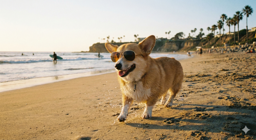

  - A white Persian cat is sleeping  (data/raw_images/cat.png)


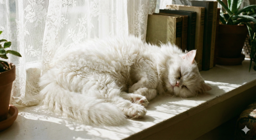

  - Cyberpunk-style streets, neon lights  (data/raw_images/neon.png)


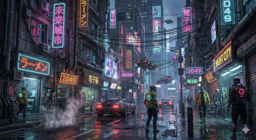

In [9]:
import json

from IPython.display import display
from PIL import Image

assert os.path.exists(cfg.JSONL_PATH), f"缺少 {cfg.JSONL_PATH}"

with open(cfg.JSONL_PATH) as f:
    items = [json.loads(line) for line in f]

print(f"共 {len(items)} 条样本:")
for it in items:
    img_path = os.path.join(cfg.PROJECT_ROOT, it["image"])
    print(f"  - {it['text']}  ({it['image']})")
    if os.path.exists(img_path):
        img = Image.open(img_path).convert("RGB")
        img.thumbnail((256, 256))
        display(img)

## 四、预处理（Preprocess）

把每张图编码进 latent，并把文本编码成两组 embedding。

### 4.1 VAE 编码：缩放因子 0.13025 是怎么来的？

VAE 编码器 $\mathcal{E}$ 把 $H{\times}W{\times}3$ 的图像压到 $\frac{H}{8}{\times}\frac{W}{8}{\times}4$ 的 latent，记 $z = \mathcal{E}(x)$。 SDXL 训练时统计出 latent 的标准差约为 $7.67$，扩散模型希望输入接近 $\mathcal{N}(0, I)$，所以乘一个**缩放因子** $s = 1/7.67 \approx 0.13025$：

$$
z_{\text{scaled}} = s \cdot \mathcal{E}(x), \qquad \hat{x} = \mathcal{D}\!\left( \frac{z_{\text{scaled}}}{s} \right)
$$

对应代码：`preprocess.py` 里 `latents = vae.encode(...).sample() * 0.13025`，`inference.py` 里 `latents = latents / 0.13025`。**任何时候这两个值必须严格匹配**。

### 4.2 图像归一化
$$
\tilde{x}_{ij} = \frac{x_{ij}}{127.5} - 1 \in [-1, 1]
$$

### 4.3 文本编码
- **CLIP-L** 输出 `pooler_output`：句子级 768 维向量 $c_{\text{clip}}$，作为**全局**条件
- **Qwen2.5-1.5B** 取最后一层 hidden states：`(128, 1536)` 序列 $c_{\text{qwen}}$，作为 cross-attention 的 KV

### 4.4 多分辨率分桶（Aspect-ratio Bucketing）
原图 $(w, h)$ 按宽高比 $r = w/h$ 找最近桶 $(b_w, b_h)$：
$$
(b_w^*, b_h^*) = \arg\min_{(b_w, b_h) \in \mathcal{B}} \left| r - \frac{b_w}{b_h} \right|
$$
缩放系数 $s' = \max(b_w/w, b_h/h)$（先放大到能盖住目标），然后中心裁剪。这样每张图的 latent 形状只能是 7 种之一，DataLoader 才能 batch。

⚠️ 第一次运行会自动从 HuggingFace 下载 VAE / CLIP / Qwen 模型权重（合计 ~6 GB），需要几分钟。

In [10]:
from qfm.engine.preprocess import main as run_preprocess

run_preprocess()

🚀 Starting Preprocess on cuda with torch.bfloat16
⏳ Loading Models...


`torch_dtype` is deprecated! Use `dtype` instead!


✅ Models Loaded.
📊 Found 3 images. Processing...


100%|██████████| 3/3 [00:26<00:00,  8.75s/it]

✅ Done! Processed 3 images.
📄 Index saved to /home/yao/projects/QFM/data/processed/processed_index.json


In [11]:
# 看看产出的 latent / embedding 长啥样
import json

import torch

with open(cfg.PROCESSED_INDEX_PATH) as f:
    idx = json.load(f)
print(f"Processed samples: {len(idx)}")
for entry in idx:
    print(" -", entry)

sample = torch.load(os.path.join(cfg.PROCESSED_DATA_DIR, idx[0]["file"]), weights_only=False)
for k, v in sample.items():
    if torch.is_tensor(v):
        print(f"{k:14s} shape={tuple(v.shape)} dtype={v.dtype}")
    else:
        print(f"{k:14s} = {v}")

Processed samples: 3
 - {'file': '00000000.pt', 'shape': [48, 80]}
 - {'file': '00000001.pt', 'shape': [48, 80]}
 - {'file': '00000002.pt', 'shape': [48, 80]}
vae_latent     shape=(4, 48, 80) dtype=torch.bfloat16
clip_embeds    shape=(768,) dtype=torch.bfloat16
qwen_embeds    shape=(128, 1536) dtype=torch.bfloat16
bucket_res     = (384, 640)


## 五、Flow Matching 数学原理（重点）

扩散模型可以理解成**学一个把噪声分布 $p_0=\mathcal{N}(0,I)$ 逐渐变形到数据分布 $p_1 = p_{\text{data}}$ 的 ODE**：

$$
\frac{dx_t}{dt} = v_\theta(x_t, t, c), \qquad x_0 \sim p_0, \; t \in [0, 1]
$$

**问题**：怎么得到 $v_\theta$ 的训练目标？传统 DDPM 走的是"学得分函数 $\nabla\log p_t$"那一套，公式很复杂。Flow Matching 给出了一个**远更简单**的方案。

### 5.1 Rectified Flow：直线插值
在每个数据点 $x_1$ 和一个独立采样的噪声 $x_0$ 之间画**一条直线**：

$$
\boxed{\; x_t = (1-t)\, x_0 + t\, x_1 \;}
$$

对 $t$ 求导得到这条直线上的瞬时速度：

$$
\boxed{\; \frac{dx_t}{dt} = x_1 - x_0 \;}
$$

这就是 **目标速度场**。它的形式特别干净：常数（沿这条线）。

### 5.2 训练损失
用 MSE 让网络拟合这个目标：

$$
\boxed{\;
\mathcal{L}_{\text{FM}}(\theta) = \mathbb{E}_{\substack{x_1 \sim p_{\text{data}} \\ x_0 \sim \mathcal{N}(0,I) \\ t \sim \mathcal{U}(0,1)}} \left[ \left\| v_\theta\!\left((1-t)x_0 + t\, x_1,\; t,\; c\right) - (x_1 - x_0) \right\|^2 \right]
\;}
$$

**对应代码**（`trainer.py: training_step`）：
```python
t      = torch.rand(B, device=...)             # t ~ U(0,1)
x_0    = torch.randn_like(x_1)                  # 噪声
x_t    = t·x_1 + (1-t)·x_0                      # 线性插值
v_tgt  = x_1 - x_0                              # 目标速度
v_pred = model(x_t, t, clip_emb, qwen_emb)
L_mse  = ((v_pred - v_tgt)**2).mean()
```

### 5.3 为什么叫 "Rectified" Flow？
如果目标分布只有一个点，最优 ODE 路径就是直线，这时 $v_\theta$ 是常数 → **采样可以一步到位**。当数据分布有很多点时直线会交叉，但可以反复"reflow"把交叉拉直。这是 **Stable Diffusion 3 / Flux** 的核心思想，也是这个项目命名 "QFM" 的由来。

### 5.4 时间嵌入（Sinusoidal）
把标量 $t \in [0,1]$ 映射成 256 维向量，喂给网络：

$$
\omega_i = \exp\!\left( -\frac{i \log 10000}{d/2 - 1} \right), \quad
\text{TE}(t) = \bigl[ \sin(t\,\omega_0), \cos(t\,\omega_0), \dots, \sin(t\,\omega_{d/2-1}), \cos(t\,\omega_{d/2-1}) \bigr]
$$

对应 `model_moe.py: get_timestep_embedding`，再过一个两层 MLP。

### 5.5 条件注入：AdaLN-Zero
`MoEDiTBlock` 把时间嵌入和 CLIP pooled 向量拼起来 $c = [\text{TE}(t); c_{\text{clip}}]$，过 `cond_proj` 再过一个 SiLU+Linear，**输出 9·hidden_size 维**，切成 9 块用于三处 LayerNorm 调制：

$$
\text{Modulate}(x; \gamma, \beta) = (1+\gamma)\odot \text{LN}(x) + \beta
$$

每个 block 的前向（自注意力 / 交叉注意力 / MoE 各 3 个参数 = 9）：

$$
\begin{aligned}
x &\leftarrow x + g_{\text{sa}} \cdot \text{Attn}\bigl(\text{Mod}(\text{LN}(x); s_{\text{sa}}, b_{\text{sa}})\bigr) \\
x &\leftarrow x + g_{\text{ca}} \cdot \text{CrossAttn}\bigl(Q{=}\text{Mod}(\text{LN}(x);\dots),\, K{=}V{=}c_{\text{qwen}}\bigr) \\
x &\leftarrow x + g_{\text{moe}} \cdot \text{MoE}\bigl(\text{Mod}(\text{LN}(x);\dots)\bigr)
\end{aligned}
$$

**Zero-init 技巧**：`adaLN_modulation` 的最后一层 weight/bias 全部初始化为 0。这样训练开始时 $\gamma=\beta=g=0$，整个 block 退化成恒等映射 $x \leftarrow x$，相当于一个非常稳定的起点。

### 5.6 Sparse MoE 与负载均衡
对每个 token $h \in \mathbb{R}^d$，路由器算 $E$ 维 logits 后取 top-2：

$$
p = \text{softmax}(W_g h) \in \Delta^{E-1}, \quad
(\mathcal{T}, w) = \text{TopK}(p, k{=}2), \quad
\tilde{w}_k = \frac{w_k}{w_1 + w_2}
$$

输出是被选中两个专家的加权和：

$$
\text{MoE}(h) = \sum_{k=1}^{2} \tilde{w}_k \cdot E_{\mathcal{T}_k}(h)
$$

**负载均衡 Loss**（防止专家坍塌——所有 token 都选同一个专家）：定义
- $f_i$ = 路由到专家 $i$ 作为 top-1 的 token 比例
- $P_i$ = 整批 token 中分配给专家 $i$ 的平均概率

$$
\boxed{\; \mathcal{L}_{\text{aux}} = E \cdot \sum_{i=1}^{E} f_i \cdot P_i \;}
$$

理想情况均匀分配 $f_i = P_i = 1/E$，此时 $\mathcal{L}_{\text{aux}} = E \cdot E \cdot (1/E)^2 = 1$（最小值）。

### 5.7 总损失
$$
\boxed{\; \mathcal{L} = \mathcal{L}_{\text{FM}} + 0.01 \cdot \mathcal{L}_{\text{aux}} \;}
$$

### 5.8 优化器与学习率
- **AdamW**: $\theta \leftarrow \theta - \eta\, \widehat{m}_t / (\sqrt{\widehat{v}_t} + \epsilon) - \eta \lambda \theta$（weight_decay = $10^{-4}$）
- **Linear warmup**（前 2000 步）：
$$
\eta(s) = \eta_{\max} \cdot \Bigl[\,0.01 + (1 - 0.01) \cdot \min\!\bigl(1,\, s/2000\bigr)\Bigr]
$$
- **梯度裁剪**：$\| g \|_2 \le 1.0$
- **梯度累积**：每 4 个 mini-batch 才 step 一次，等效 batch size = `4 × accumulate_grad_batches`

### 5.9 EMA（影子权重）
$$
\theta^{\text{EMA}} \leftarrow \alpha\, \theta^{\text{EMA}} + (1 - \alpha)\, \theta, \qquad \alpha = 0.9999
$$
训练时用 $\theta$，推理 / 验证时用 $\theta^{\text{EMA}}$，能显著降低 FID。

### 5.10 跑一次训练（smoke test 模式）

训练入口是 `qfm.engine.trainer.run_training()`，里面用 PyTorch Lightning 串起上述所有组件。

> **关于日志**：项目原来用 WandB，现在已经改成本地 **CSVLogger** — 训练曲线写到 `checkpoints/qfm_logs/version_*/metrics.csv`，**不需要登录任何在线服务**。  
> ⚠️ 如果在同一个 kernel 里改过 `trainer.py` 之类的 `.py` 文件，请先 **Restart Kernel** 让新代码生效。

**为什么 notebook 里要缩小模型？**  
默认配置是 ~1 B 参数：训练本身在 3090Ti 上每 step 也就秒级，但 Lightning 每 epoch 末尾要把 **`模型权重 + EMA 影子权重 + Adam 优化器状态(m,v)` ≈ 14 GB** 写盘，再叠上 `save_top_k=3, save_last=True` 可能写两个文件 → WSL 虚拟磁盘 IO 慢的话 60+ 秒。这会让 notebook 像"卡死"。

下面 cell 把模型缩到 ~5 M 参数（hidden=256, depth=2, experts=2），整个 smoke test < 30 秒。**等你有了真正的数据集**，把那个 cell 整段注释掉再跑 `run_training()`，或者直接 `python main.py train` 用全尺寸。

In [7]:
# ─── Smoke-test 模式：仅本 notebook 内覆盖 cfg，让训练快速跑通 ───
# ⚠️ 等你补足训练数据后，把整个 cell 注释掉，用 `python main.py train` 跑真实尺寸。

# 1) 训练超参
cfg.train.epochs = 2
cfg.train.save_interval = 1
cfg.train.batch_size = 1  # 3 张图，batch=1 看 3 个 step
cfg.train.accumulate_grad_batches = 1
cfg.train.validation_interval = 10_000  # 关掉训练中验证生图

# 2) 模型尺寸：默认 1B 参数对 3 张图毫无意义，
#    且 1B 模型 + EMA + Adam → 每个 checkpoint 要写 ~14 GB（WSL 慢盘 60 秒+）。
#    缩到 ~5 M 参数，存盘是秒级。
cfg.model.hidden_size = 256  # default 1024
cfg.model.depth = 2  # default 12
cfg.model.num_heads = 8  # default 16
cfg.model.num_experts = 2  # default 8

print("Effective train cfg:", cfg.train)
print("Effective model cfg:", cfg.model)

Effective train cfg: TrainingArgs(batch_size=1, lr=5e-05, epochs=2, accumulate_grad_batches=1, grad_clip=1.0, seed=42, save_interval=1, log_interval=10, validation_interval=10000)
Effective model cfg: ModelArgs(input_size=64, patch_size=2, in_channels=4, hidden_size=256, depth=2, num_heads=8, num_experts=2, qwen_dim=1536, clip_dim=768)


In [12]:
# （可选）验证一下分桶 Sampler 真的能产生 batch
# 之前一个 bug：__len__ 算式错了，小数据集会返回 0，导致 "No training batches"。
# 已在 trainer.py 修复，这里跑一遍确认。
from qfm.dataset import LatentDataset
from qfm.engine.trainer import BucketedBatchSampler

_ds = LatentDataset()
_smp = BucketedBatchSampler(_ds, batch_size=cfg.train.batch_size, shuffle=True)

print(f'len(sampler) = {len(_smp)}  (Lightning 用这个判断"有没有 batch")')
batches = list(_smp)
print(f"实际产生 batch 数 = {len(batches)}")
for i, b in enumerate(batches):
    print(f"  batch {i}: indices {b}")

assert len(_smp) > 0, "❌ 没有 batch，检查 data/processed 是否有 .pt 文件"

Dataset: Loaded 3 samples from index.
len(sampler) = 3  (Lightning 用这个判断"有没有 batch")
实际产生 batch 数 = 3
  batch 0: indices [2]
  batch 1: indices [0]
  batch 2: indices [1]


In [13]:
from qfm.engine.trainer import run_training

run_training()

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


⚡ Single GPU/MPS Detected. Using Auto strategy.
[2026-04-25 21:12:58] [INFO] 🚀 Starting PyTorch Lightning Training...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Dataset: Loaded 3 samples from index.
[2026-04-25 21:12:58] [INFO] ✅ EMA initialized (decay=0.9999, every=10 steps)



  | Name  | Type        | Params | Mode  | FLOPs
------------------------------------------------------
0 | model | MiniFluxDiT | 6.3 M  | train | 0    
------------------------------------------------------
6.3 M     Trainable params
0         Non-trainable params
6.3 M     Total params
25.262    Total estimated model params size (MB)
61        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 1: 100%|██████████| 3/3 [00:00<00:00, 12.20it/s, v_num=0, train/loss=1.630, lr=6.24e-7]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 3/3 [00:00<00:00,  5.53it/s, v_num=0, train/loss=1.630, lr=6.24e-7]


In [9]:
# 训练后，看一下产出的 checkpoint
import os

from qfm.config import cfg

ckpts = sorted(
    [f for f in os.listdir(cfg.CKPT_DIR) if f.endswith(".ckpt") or f.endswith(".pth")],
    key=lambda x: os.path.getmtime(os.path.join(cfg.CKPT_DIR, x)),
)
for c in ckpts:
    full = os.path.join(cfg.CKPT_DIR, c)
    size_mb = os.path.getsize(full) / 1024 / 1024
    print(f"{c:50s} {size_mb:7.1f} MB")

last.ckpt                                             96.5 MB
last.pth                                              24.1 MB


## 六、推理：Euler ODE 采样

训练只学到了 $v_\theta$，**生成阶段需要解 ODE**：

$$
\frac{dx_t}{dt} = v_\theta(x_t, t, c), \qquad x_0 \sim \mathcal{N}(0, I), \quad x_1 = ?
$$

### 6.1 显式 Euler 离散化
把 $[0,1]$ 等分成 $N$ 步（这里 `num_steps=20`），步长 $\Delta t = 1/N$。从 $i=0$ 开始迭代：

$$
\boxed{\;
t_i = \frac{i}{N}, \qquad x_{t_{i+1}} = x_{t_i} + v_\theta(x_{t_i}, t_i, c)\, \Delta t
\;}
$$

对应 `utils.py: flux_ode_euler`：
```python
for i in range(num_steps):
    t = i / num_steps
    v = model(latents, t, clip_vec, qwen_emb)
    latents = latents + v * (1 / num_steps)
```

### 6.2 生成阶段完整流程
$$
\text{prompt}
\xrightarrow[\text{CLIP+Qwen}]{}
c
\quad,\quad
x_0 \sim \mathcal{N}(0, I_{4 \times h/8 \times w/8})
\xrightarrow[\text{Euler ODE}]{N \text{ steps}}
x_1
\xrightarrow[\div\, 0.13025]{}
z
\xrightarrow[\text{VAE}\,\mathcal{D}]{}
\hat{x} \in [-1, 1]
\xrightarrow[\div 2 + 0.5]{}
[0,1]\text{ image}
$$

### 6.3 任意分辨率怎么办？
训练时 `pos_embed` 是按 64×64 = 4096 个 patch 学的。当推理生成 $h{\times}w$ 不同分辨率时，把 `pos_embed` reshape 回 $32{\times}32$ 网格，用 **bicubic 插值**到目标 $\frac{h}{16}{\times}\frac{w}{16}$，再 flatten 回去。这样不用重训就能跑 1024×512 / 384×640 等。

### 6.4 准备 checkpoint 并采样
Lightning 存的 `.ckpt` 文件结构是 `{'state_dict': {'model.xxx.weight': ...}}`，而 `run_inference` 读的是裸 state_dict，下面这段会做一次自动转换并存成 `.pth`。

In [10]:
import os

import torch

from qfm.config import cfg

latest = os.path.join(cfg.CKPT_DIR, ckpts[-1])
print("Latest ckpt:", latest)

if latest.endswith(".ckpt"):
    blob = torch.load(latest, map_location="cpu", weights_only=False)
    raw = blob.get("state_dict", blob)
    # Lightning 的 key 形如 'model.x_embedder.weight'，去掉 'model.' 前缀
    clean = {k[len("model.") :]: v for k, v in raw.items() if k.startswith("model.")}
    pth_path = latest.replace(".ckpt", ".pth")
    torch.save(clean, pth_path)
    inf_ckpt = pth_path
    print(f"Converted -> {pth_path}  ({len(clean)} tensors)")
else:
    inf_ckpt = latest

Latest ckpt: /home/yao/projects/QFM/checkpoints/last.pth


[2026-04-25 21:15:10] [INFO] 🎨 Inference task started on cuda (torch.bfloat16)
[2026-04-25 21:15:10] [INFO]    Prompt: "A cyberpunk city with neon lights"
[2026-04-25 21:15:10] [INFO]    Resolution: 512x512
[2026-04-25 21:15:10] [INFO]    Checkpoint: /home/yao/projects/QFM/checkpoints/last.pth
[2026-04-25 21:15:10] [INFO] Loading generic models (VAE, CLIP, Qwen)...
[2026-04-25 21:15:16] [INFO] Loading DiT model...
[2026-04-25 21:15:16] [INFO] ✅ DiT weights loaded successfully.
[2026-04-25 21:15:16] [INFO] Generating image...
[2026-04-25 21:15:17] [INFO] ✨ Success! Image saved to: /home/yao/projects/QFM/docs/demo_result.png


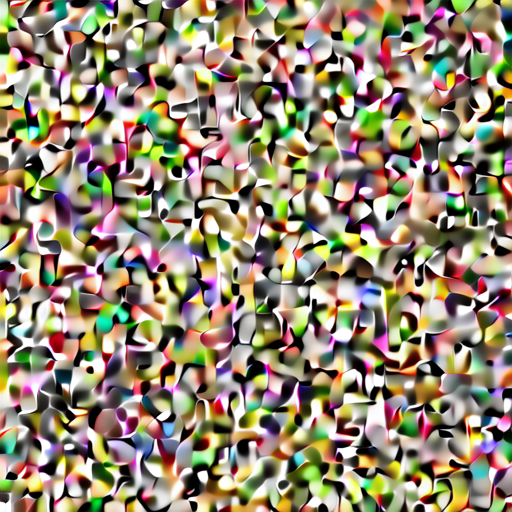

In [11]:
import os

from IPython.display import display
from PIL import Image

from qfm.config import cfg
from qfm.engine.inference import run_inference

out = os.path.join(cfg.PROJECT_ROOT, "docs", "demo_result.png")
run_inference(
    ckpt_path=inf_ckpt,
    prompt="A cyberpunk city with neon lights",
    output_path=out,
    steps=20,
    width=512,
    height=512,
    seed=42,
)

display(Image.open(out))

## 七、下一步

**这个 notebook 跑出来的图基本是噪声** — 3 张图 + 2 个 epoch 离收敛差几个数量级，目的只是验证管线打通。等你补足训练数据后：

1. **数据**：`data/raw_images/` 至少几百到几千张图，并补全 `data/data.jsonl`
2. **超参**：把 `cfg.train.epochs` 调回 50+、`batch_size` 视显存调到 4–8
3. **运行**：直接命令行 `python main.py preprocess` → `python main.py train` → `python main.py inference --prompt "..."`
4. **多分辨率**：推理时 `--width 1024 --height 512` 试试 21:9 / 16:9 桶
5. **多卡**：trainer 已自动检测 `>1` 张 GPU 并切到 DDP，无需改代码

### 调参 checklist
- 数据 < 1k 张时 `lr` 调到 $1\text{e-}4$ 反而更稳
- Loss 不降：检查 latent 是否乘了 `0.13025`、`bf16` 是否触发数值不稳（Mac MPS 上必须用 `float32`）
- 生成图全灰：训练步数不够；或 EMA 还没 warm up（前 100 步用原始权重）
- 专家坍塌（aux_loss 一直在 1.0 附近不降）：`num_experts` 改小，或路由器 LR 单独放大